In [2]:
import sys
import os




project_path = r"C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder"
if project_path not in sys.path:
    sys.path.append(project_path)

import track_builder as tb

import pandas as pd
import track_builder as tb

import os
from dotenv import load_dotenv

load_dotenv()

saving_path = os.getenv("SAVING")
track_output_path = os.path.join(saving_path, "tracks")
df_output_path = os.path.join(saving_path, "df")
os.makedirs(track_output_path, exist_ok=True)
os.makedirs(df_output_path, exist_ok=True)

BASE_PATH = r"C:\Users\lamin\Documents\maitrise\ASTD\data"
YEAR      = 2019

MONTHS_TO_LOAD = [1, 2, 3]

USECOLS   = "default"
SAMPLING  = [0, -1]

COLS_REQUIRED = [
    "shipid",
    "date_time_utc",
    "latitude",
    "longitude",
    "astd_cat",
    "flagname",
    "iceclass",
    "sizegroup_gt"
]


In [3]:
periods = {
    2019: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],  # Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec
    2020: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]      # Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec
}

In [4]:
df_parquet_file = os.path.join(df_output_path, "first_and_last_of_24month_2019_2020_astd_data.parquet")

if os.path.exists(df_parquet_file):
    df_for_track = pd.read_parquet(df_parquet_file)
else:
    df_for_track = tb.load_astd_periods(
        BASE_PATH, periods, progress=True,
        usecols=USECOLS, sampling=SAMPLING, remove_nan_rows=COLS_REQUIRED
    )

    
    df_for_track.to_parquet(df_parquet_file, index=False)

df_for_track

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
0,3994,2019-01-01 00:00:02+00:00,Norway,FS Ice Class 1C,Offshore supply ships,1000 - 4999 GT,8.541162,371,5.850370,62.335602
1,5966,2019-01-01 00:00:02+00:00,Russia,FS Ice Class 1A,General cargo ships,10000 - 24999,616.758301,971,72.985146,73.034294
2,3768,2019-01-01 00:00:02+00:00,Netherlands,FS Ice Class 1C,Other service offshore vessels,10000 - 24999,0.000000,718,7.734500,63.110500
3,1541,2019-01-01 00:00:04+00:00,Norway (Nis),FS Ice Class 1C,Passenger ships,1000 - 4999 GT,0.000000,364,7.733963,63.113628
4,1892,2019-01-01 00:00:04+00:00,Russia,FS Ice Class 1C,Fishing vessels,< 1000 GT,1.028629,540,29.700306,70.626442
...,...,...,...,...,...,...,...,...,...,...
5818197,7312,2020-12-31 23:59:53+00:00,Norway,FS Ice Class 1C,Offshore supply ships,1000 - 4999 GT,239.384995,370,8.048237,65.995064
5818198,5668,2020-12-31 23:59:53+00:00,Russia,FS Ice Class 1A,General cargo ships,1000 - 4999 GT,2091.924072,370,11.443626,67.315842
5818199,1199,2020-12-31 23:59:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.849000,661,-22.425282,63.839603
5818200,2102,2020-12-31 23:59:57+00:00,Russia,FS Ice Class 1B,Fishing vessels,1000 - 4999 GT,3.224000,361,30.032101,69.728386


In [5]:
df_parquet_file2 = os.path.join(df_output_path, "all_24month_2019_2020_astd_data2_without_nan_col.parquet")

if os.path.exists(df_parquet_file2):
    df = pd.read_parquet(df_parquet_file2)
else:
    df = tb.load_astd_periods(
        BASE_PATH, periods=periods, progress=True,
        usecols=USECOLS, sampling=None, remove_nan_rows=COLS_REQUIRED
    )
    
    df.to_parquet(df_parquet_file2, index=False)

df

,shipid,date_time_utc,flagname,iceclass,astd_cat,sizegroup_gt,dist_nextpoint,sec_nextpoint,longitude,latitude
0,3994,2019-01-01 00:00:02+00:00,Norway,FS Ice Class 1C,Offshore supply ships,1000 - 4999 GT,8.541162,371,5.850370,62.335602
1,5966,2019-01-01 00:00:02+00:00,Russia,FS Ice Class 1A,General cargo ships,10000 - 24999,616.758301,971,72.985146,73.034294
2,3768,2019-01-01 00:00:02+00:00,Netherlands,FS Ice Class 1C,Other service offshore vessels,10000 - 24999,0.000000,718,7.734500,63.110500
3,1541,2019-01-01 00:00:04+00:00,Norway (Nis),FS Ice Class 1C,Passenger ships,1000 - 4999 GT,0.000000,364,7.733963,63.113628
4,3009,2019-01-01 00:00:04+00:00,Norway,FS Ice Class 1C,Fishing vessels,< 1000 GT,1945.192749,371,25.147583,70.990837
...,...,...,...,...,...,...,...,...,...,...
88414243,5668,2020-12-31 23:59:53+00:00,Russia,FS Ice Class 1A,General cargo ships,1000 - 4999 GT,2091.924072,370,11.443626,67.315842
88414244,7312,2020-12-31 23:59:53+00:00,Norway,FS Ice Class 1C,Offshore supply ships,1000 - 4999 GT,239.384995,370,8.048237,65.995064
88414245,1199,2020-12-31 23:59:54+00:00,Iceland,FS Ice Class 1C,Fishing vessels,< 1000 GT,0.849000,661,-22.425282,63.839603
88414246,537,2020-12-31 23:59:57+00:00,Finland,FS Ice Class 1A Super,Passenger ships,25000 - 49999,3560.430908,365,19.867016,59.922009


In [6]:
# verify if .parquet file exists, if yes load it, else build tracks and save it
parquet_file_path = os.path.join(track_output_path, "tracks_for_24_month_2019_2020.parquet")

if os.path.exists(parquet_file_path):
    tracks = pd.read_parquet(parquet_file_path)
else:
    tracks = tb.build_ship_tracks(df_for_track,
                                  max_time_gap_hours=25,
                                  max_distance_km=400,
                                  min_track_length=1,
                                  matching_strategy="balanced",
                                  return_logs=False,
                                  )
    tracks.to_parquet(parquet_file_path)

tracks

,month,segment_id,track_id
0,2019-01,3994,1
1,2019-02,3742,1
2,2019-03,4018,1
3,2019-04,4705,1
4,2019-05,4311,1
...,...,...,...
26594,2020-12,5204,10924
26595,2020-12,8023,10925
26596,2020-12,5902,10926
26597,2020-12,8026,10927


computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 2278 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



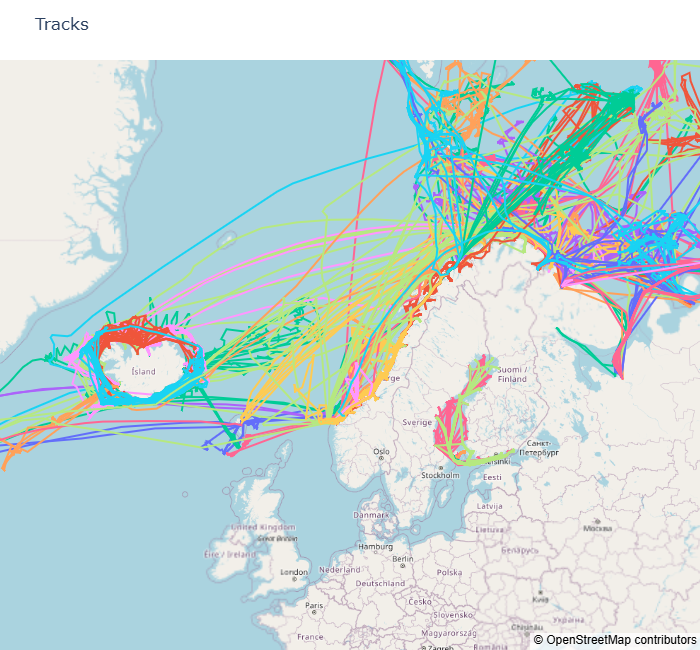

In [ ]:
work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=50,
                                        positions_df=df, n_tracks_length=[8, 14], 
                                        preprocess_positions=True, )

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks",
)
fig.update_layout(showlegend=False)
fig.show()

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 78 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



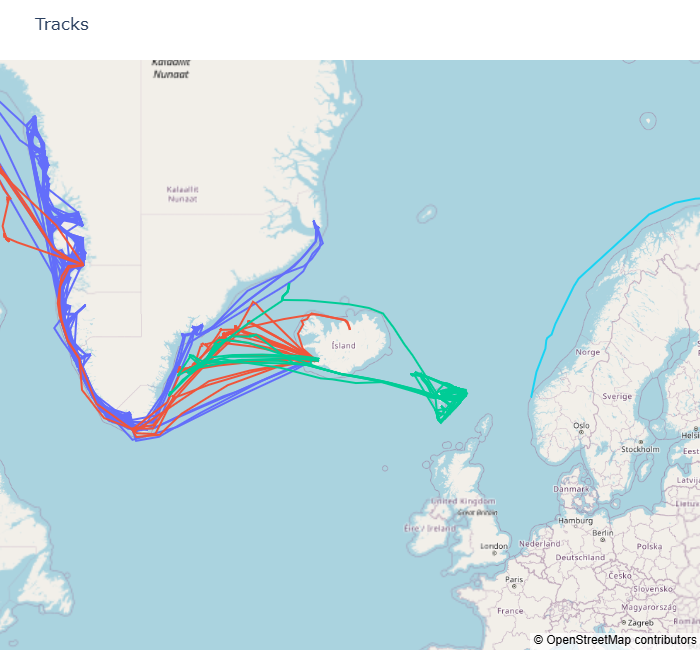

In [ ]:
work = tb.build_light_multi_track_data(track_table=tracks, specific_track_ids=[2748, 2741, 543, 3845, 4009, 3076],
                                        positions_df=df, 
                                        preprocess_positions=True, )

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks",
)
fig.update_layout(showlegend=False)
fig.show()

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 33731 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



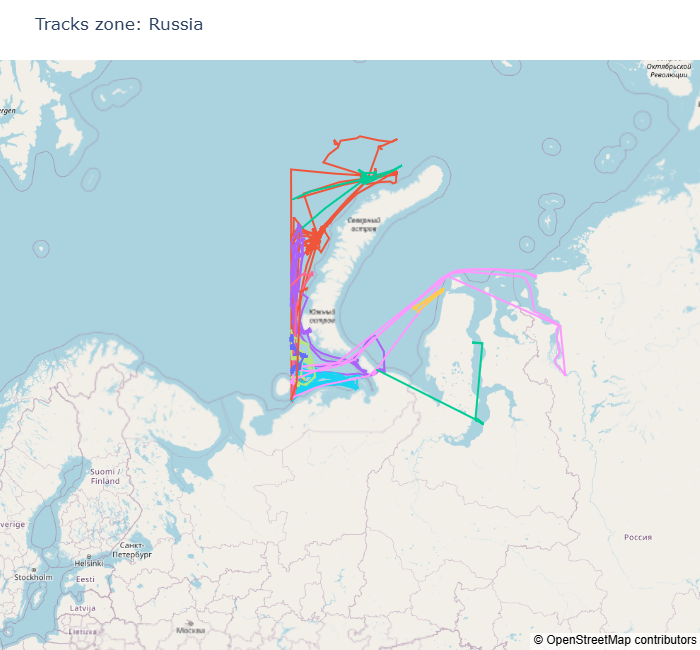

In [ ]:

work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=50,
                                        positions_df=df, n_tracks_length=12, 
                                        preprocess_positions=True, region="russia")

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks zone: Russia",
)
fig.update_layout(showlegend=False)
fig.show()

computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 33731 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



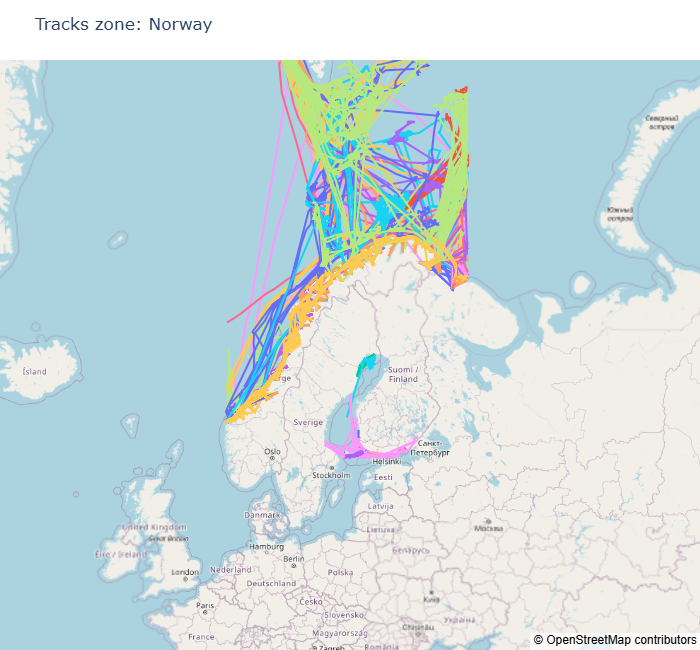

In [ ]:

work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=50,
                                        positions_df=df, n_tracks_length=12, 
                                        preprocess_positions=True, region="norway")

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks zone: Norway",
)
fig.update_layout(showlegend=False)
fig.show()

In [11]:
track_504 = tb.load_track_data(track_ids=[504], track_table=tracks, base_path=BASE_PATH, chunksize=500_000)

c:\Users\lamin\miniconda3\envs\astd-track\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

Batch loading 1 tracks: 100%|██████████| 5/5 [02:16<00:00, 27.33s/it]


computing typical speeds...
Cleaning completed: 28 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



computing typical speeds...


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:382: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\core\track_helpers.py:170: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



Cleaning completed: 129559 'ghost' or aberrant points removed.


C:\Users\lamin\Documents\maitrise\ASTD\TrackBuilder\track_builder\io\astd_loader.py:587: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



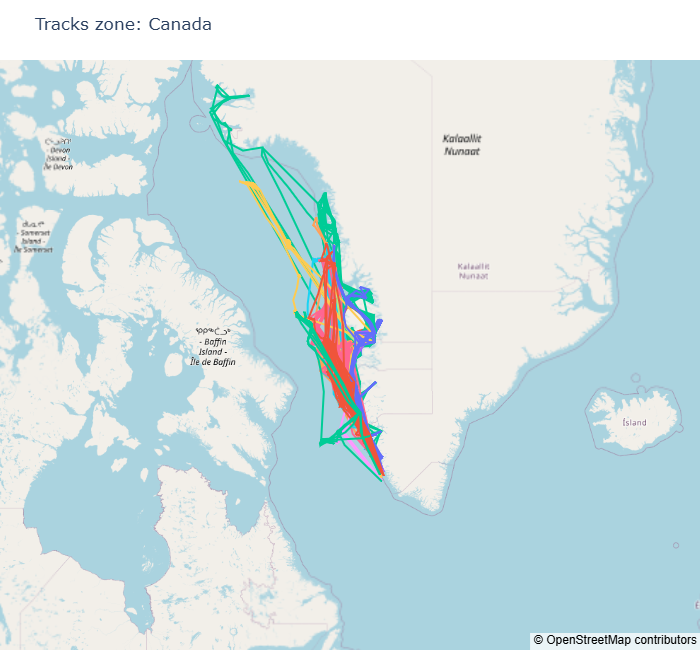

In [ ]:

work = tb.build_light_multi_track_data(track_table=tracks, track_sampling=200,
                                        positions_df=df, n_tracks_length=12, 
                                        preprocess_positions=True, region="canada")

fig = tb.plot_ship_tracks(
    work,
    color_by="track_id",
    color_mode="categorical",
    show_points=False,
    map_style="open-street-map",
    title="Tracks zone: Canada",
)
fig.update_layout(showlegend=False)
fig.show()

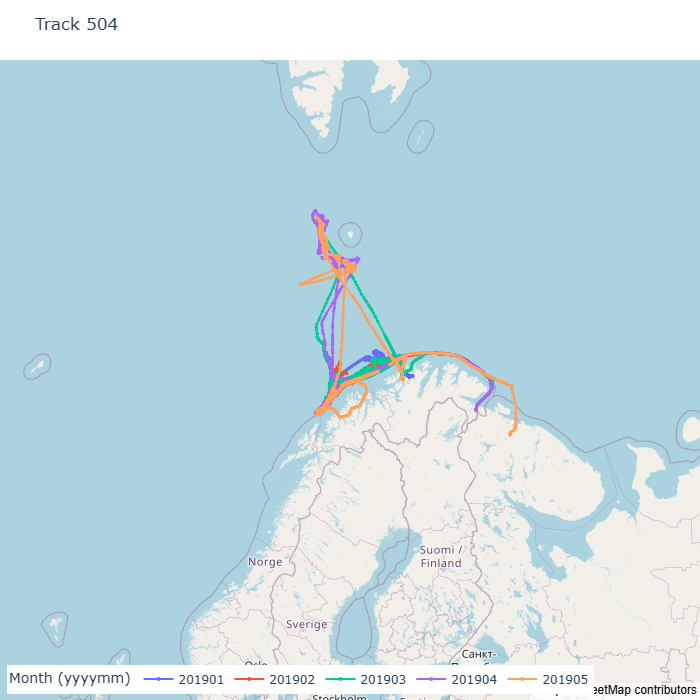

In [13]:
fig_track_504 = tb.plot_individual_track(
        track_id=504,
        track_table=tracks,
        astd_data=track_504,
        show_segments=True,
        map_style="open-street-map",
        title=f"Track {504}",
    )
    
fig_track_504.show()